In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv(r"C:\Users\saksh\Downloads\delhiaqi.csv")

print(df.head())
print(df.info())
print(df.describe())

                  date       co     no    no2    o3    so2   pm2_5    pm10  \
0  2023-01-01 00:00:00  1655.58   1.66  39.41  5.90  17.88  169.29  194.64   
1  2023-01-01 01:00:00  1869.20   6.82  42.16  1.99  22.17  182.84  211.08   
2  2023-01-01 02:00:00  2510.07  27.72  43.87  0.02  30.04  220.25  260.68   
3  2023-01-01 03:00:00  3150.94  55.43  44.55  0.85  35.76  252.90  304.12   
4  2023-01-01 04:00:00  3471.37  68.84  45.24  5.45  39.10  266.36  322.80   

     nh3  
0   5.83  
1   7.66  
2  11.40  
3  13.55  
4  14.19  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null   

In [18]:
df['date'] = pd.to_datetime(df['date'])

# extract time features
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Hour'] = df['date'].dt.hour

In [19]:
df['AQI'] = df['pm2_5']

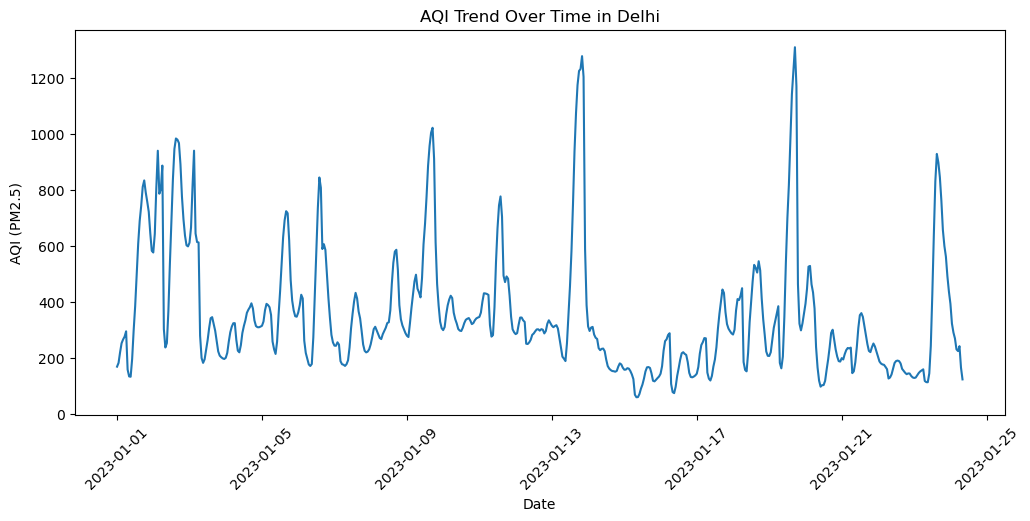

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['AQI'])
plt.title("AQI Trend Over Time in Delhi")
plt.xlabel("Date")
plt.ylabel("AQI (PM2.5)")
plt.xticks(rotation=45)
plt.show()

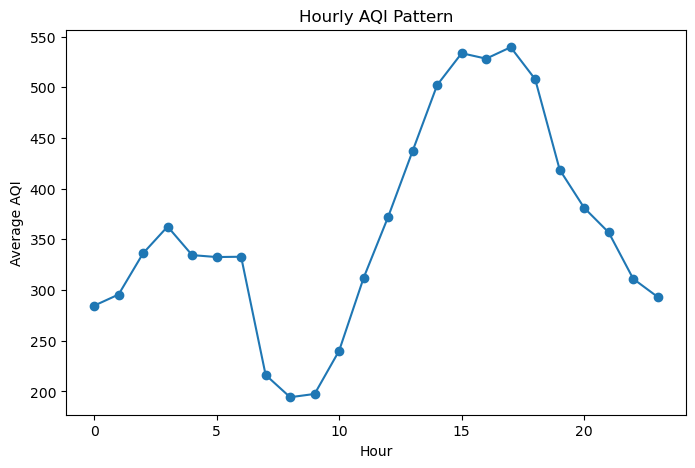

In [21]:
hourly_avg = df.groupby('Hour')['AQI'].mean()

plt.figure(figsize=(8,5))
hourly_avg.plot(kind='line', marker='o')
plt.title("Hourly AQI Pattern")
plt.ylabel("Average AQI")
plt.show()

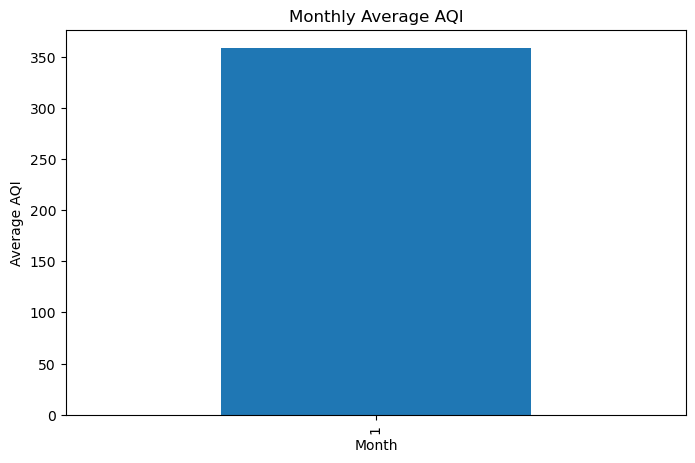

In [22]:
monthly_avg = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(kind='bar')
plt.title("Monthly Average AQI")
plt.ylabel("Average AQI")
plt.show()

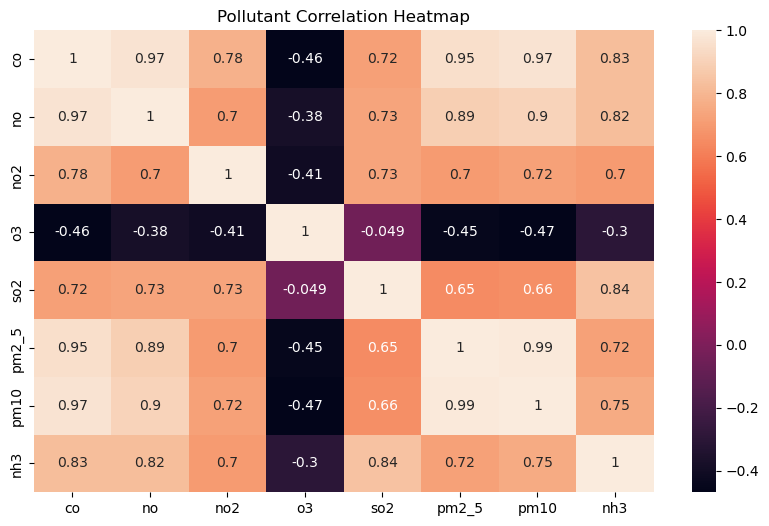

In [23]:
pollutants = ['co','no','no2','o3','so2','pm2_5','pm10','nh3']

plt.figure(figsize=(10,6))
sns.heatmap(df[pollutants].corr(), annot=True)
plt.title("Pollutant Correlation Heatmap")
plt.show()

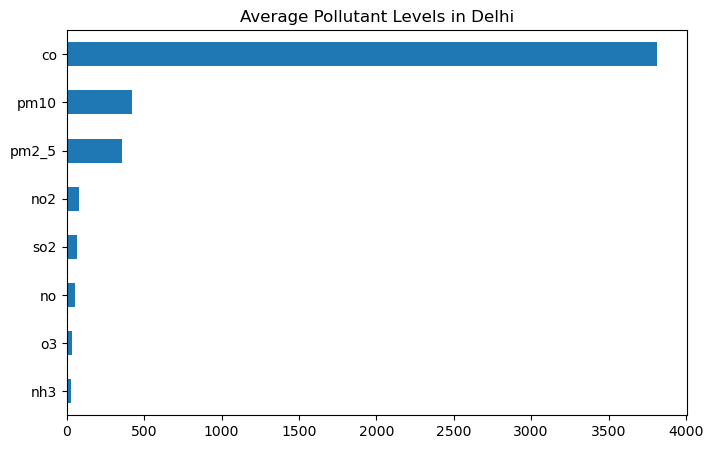

In [24]:
pollutant_means = df[pollutants].mean()

plt.figure(figsize=(8,5))
pollutant_means.sort_values().plot(kind='barh')
plt.title("Average Pollutant Levels in Delhi")
plt.show()

In [25]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)

print(df['Season'].value_counts())

Season
Winter    561
Name: count, dtype: int64


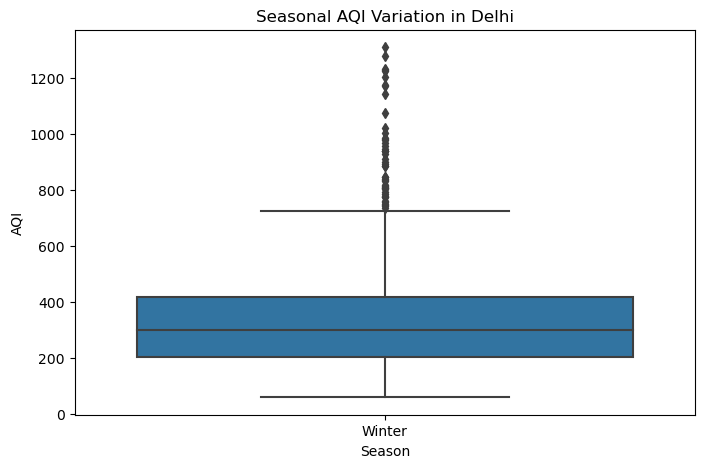

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='AQI', data=df)
plt.title("Seasonal AQI Variation in Delhi")
plt.show()

In [27]:
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

spikes = df[df['AQI'] > upper_bound]

print("Number of extreme pollution events:", len(spikes))

Number of extreme pollution events: 49


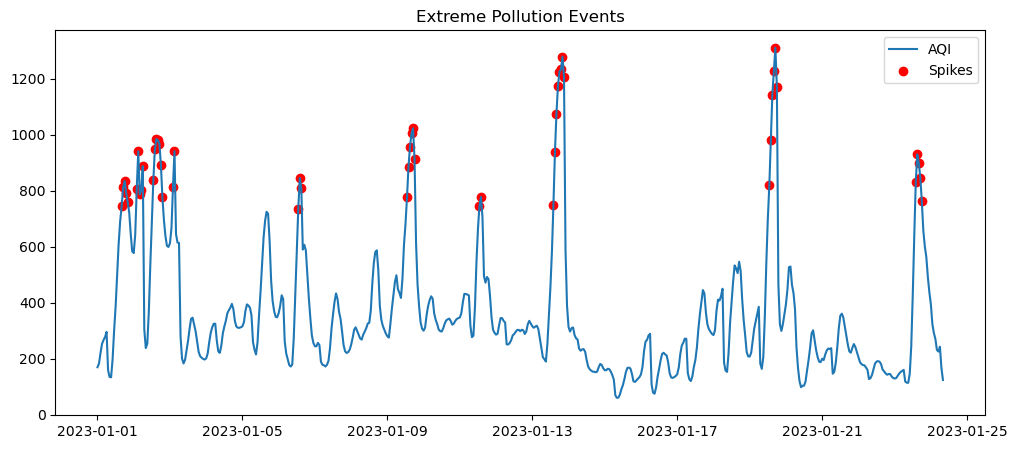

In [28]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['AQI'], label='AQI')
plt.scatter(spikes['date'], spikes['AQI'], color='red', label='Spikes')
plt.legend()
plt.title("Extreme Pollution Events")
plt.show()

In [29]:
corr_with_aqi = df.corr(numeric_only=True)['AQI'].sort_values(ascending=False)
print(corr_with_aqi)

pm2_5    1.000000
AQI      1.000000
pm10     0.994088
co       0.953083
no       0.888810
nh3      0.720303
no2      0.698696
so2      0.648996
Hour     0.191102
o3      -0.450458
Year          NaN
Month         NaN
Name: AQI, dtype: float64


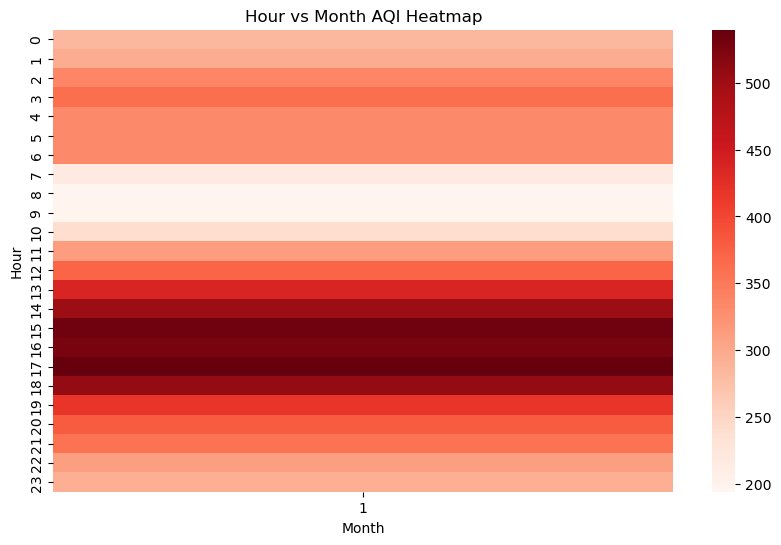

In [30]:
hour_month = df.pivot_table(values='AQI', index='Hour', columns='Month')

plt.figure(figsize=(10,6))
sns.heatmap(hour_month, cmap='Reds')
plt.title("Hour vs Month AQI Heatmap")
plt.show()

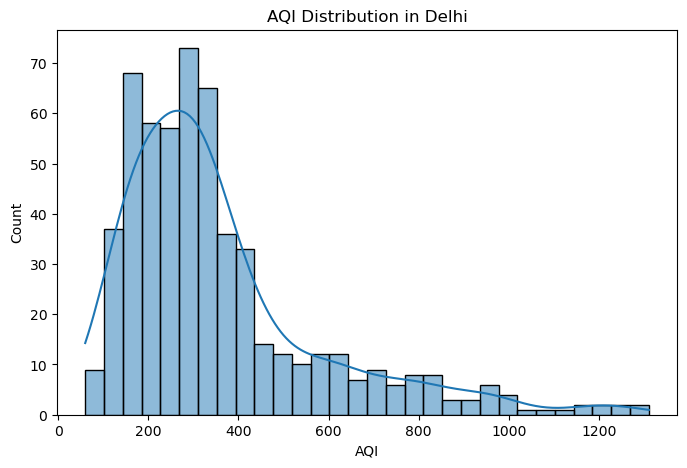

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)
plt.title("AQI Distribution in Delhi")
plt.show()

In [33]:
print(df['Season'].value_counts())

Season
Winter    561
Name: count, dtype: int64


In [34]:
season_groups = [group['AQI'].values for name, group in df.groupby('Season')]

if len(season_groups) >= 2:
    from scipy import stats
    f_stat, p_val = stats.f_oneway(*season_groups)
    print("F-statistic:", f_stat)
    print("p-value:", p_val)
else:
    print("ANOVA cannot be performed — only one season present in dataset.")

ANOVA cannot be performed — only one season present in dataset.


In [35]:
hour_groups = [group['AQI'].values for name, group in df.groupby('Hour')]

from scipy import stats
f_stat, p_val = stats.f_oneway(*hour_groups)

print("Hourly F-statistic:", f_stat)
print("Hourly p-value:", p_val)

Hourly F-statistic: 5.958509319949341
Hourly p-value: 6.702004144689513e-16
